In [2]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from PIL import Image

from torch.utils import data
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import datasets,transforms, utils, models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
USE_CUDA=torch.cuda.is_available()
DEVICE=torch.device('cuda' if USE_CUDA else 'cpu')

In [ ]:
# 기학습된 모델 불러오기
models.vgg16(pretrained=True)

c:\Users\ksa\stenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ksa\stenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\ksa/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:10<00:00, 53.6MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
import gdown, zipfile, os
import pathlib

base_dir = pathlib.Path("C:/Users/ksa/Desktop/vs/pn/deep/data/hymenoptera_data")

#1번 방식
from torchvision import transforms,datasets#데이터 전처리 목적
from torch.utils.data import DataLoader
기준경로=base_dir
이미지크기=128
배치크기=32
transform=transforms.Compose([
    #데이터 증강
    #이미지 크기 리사이즈
    transforms.Resize((이미지크기,이미지크기)),
    #텐서화
    transforms.ToTensor(),
    #스케일정리
    #이미지net의 데이터 기본 처리 방식
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])
#eval_transform
tr_ds=datasets.ImageFolder(기준경로/'train',transform=transform)
tt_ds=datasets.ImageFolder(기준경로/'test',transform=transform)
val_ds=datasets.ImageFolder(기준경로/'validation',transform=transform)

tr_ds_loader=DataLoader(tr_ds,batch_size=배치크기,shuffle=True)
tt_ds_loader=DataLoader(tt_ds,batch_size=배치크기,shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=배치크기,shuffle=True)

In [8]:
class BaseTransform:
    def __init__(self,resize,mean,std):
        self.base_transform=transforms.Compose([
            transforms.Resize(resize), # 짧은변 기준 리사이즈
            transforms.CenterCrop(resize), # 이미지 중앙 resize로 자르기
            transforms.ToTensor(), 
            transforms.Normalize(mean,std)
        ])

    def __call__(self,img):
        return self.base_transform(img)

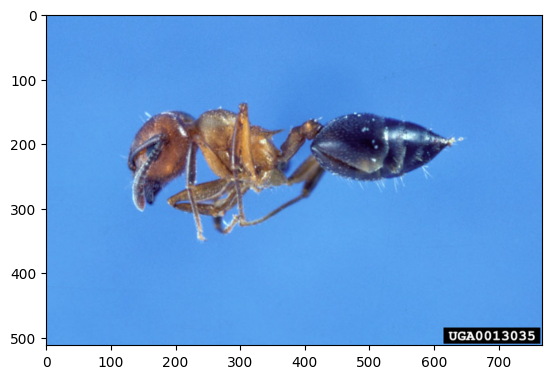

In [5]:
img_data=Image.open('C:/Users/ksa/Desktop/vs/pn/deep/data/hymenoptera_data/train/ants/0013035.jpg')
plt.imshow(img_data)
plt.show()

In [9]:
resize=224
mean=(0.485,0.456,0.406)
std=(0.229,0.224,0.225)

transform=BaseTransform(resize,mean,std)
img_tr=transform(img_data)

In [10]:
v_img_tr=img_tr.numpy().transpose((1,2,0))

In [11]:
np.clip(v_img_tr,0,1)

array([[[0.        , 0.64285725, 1.        ],
        [0.        , 0.6603642 , 1.        ],
        [0.        , 0.6603642 , 1.        ],
        ...,
        [0.        , 0.57282925, 1.        ],
        [0.        , 0.57282925, 1.        ],
        [0.        , 0.57282925, 1.        ]],

       [[0.        , 0.64285725, 1.        ],
        [0.        , 0.64285725, 1.        ],
        [0.        , 0.64285725, 1.        ],
        ...,
        [0.        , 0.6078432 , 1.        ],
        [0.        , 0.6078432 , 1.        ],
        [0.        , 0.5903362 , 1.        ]],

       [[0.        , 0.64285725, 1.        ],
        [0.        , 0.6603642 , 1.        ],
        [0.        , 0.64285725, 1.        ],
        ...,
        [0.        , 0.5903362 , 1.        ],
        [0.        , 0.5903362 , 1.        ],
        [0.        , 0.55532223, 1.        ]],

       ...,

       [[0.        , 0.7303922 , 1.        ],
        [0.        , 0.7303922 , 1.        ],
        [0.        , 0

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].


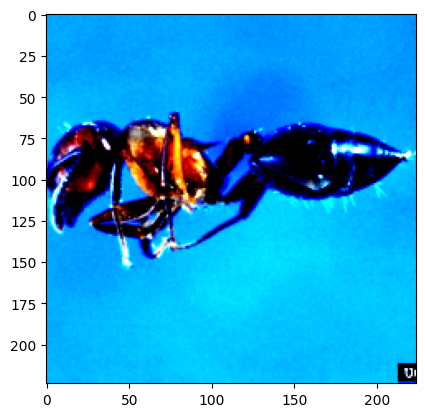

In [12]:
plt.imshow(v_img_tr)

In [14]:
ILSVRC_class_label=json.load(open('./data/imagenet_class_index.json','r'))
ILSVRC_class_label

{'0': ['n01440764', 'tench'],
 '1': ['n01443537', 'goldfish'],
 '2': ['n01484850', 'great_white_shark'],
 '3': ['n01491361', 'tiger_shark'],
 '4': ['n01494475', 'hammerhead'],
 '5': ['n01496331', 'electric_ray'],
 '6': ['n01498041', 'stingray'],
 '7': ['n01514668', 'cock'],
 '8': ['n01514859', 'hen'],
 '9': ['n01518878', 'ostrich'],
 '10': ['n01530575', 'brambling'],
 '11': ['n01531178', 'goldfinch'],
 '12': ['n01532829', 'house_finch'],
 '13': ['n01534433', 'junco'],
 '14': ['n01537544', 'indigo_bunting'],
 '15': ['n01558993', 'robin'],
 '16': ['n01560419', 'bulbul'],
 '17': ['n01580077', 'jay'],
 '18': ['n01582220', 'magpie'],
 '19': ['n01592084', 'chickadee'],
 '20': ['n01601694', 'water_ouzel'],
 '21': ['n01608432', 'kite'],
 '22': ['n01614925', 'bald_eagle'],
 '23': ['n01616318', 'vulture'],
 '24': ['n01622779', 'great_grey_owl'],
 '25': ['n01629819', 'European_fire_salamander'],
 '26': ['n01630670', 'common_newt'],
 '27': ['n01631663', 'eft'],
 '28': ['n01632458', 'spotted_salama

# 전이학습

In [18]:
class Make_dataset_Transform_tr:
    def __init__(self,resize,mean,std):
        self.base_transform=transforms.Compose([
                # 데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ])

    def __call__(self,img):
        return self.base_transform(img)
    
class Make_dataset_Transform_val:
    def __init__(self,resize,mean,std):
        self.base_transform=transforms.Compose([
            transforms.Resize(resize), # 짧은변 기준 리사이즈
            transforms.CenterCrop(resize), # 이미지 중앙 resize로 자르기
            transforms.ToTensor(), 
            transforms.Normalize(mean,std)
        ])

    def __call__(self,img):
        return self.base_transform(img)

In [43]:
resize=224
mean=(0.485,0.456,0.406)
std=(0.229,0.224,0.225)

tr_base_transform=Make_dataset_Transform_tr(resize,mean,std)
val_base_transform=Make_dataset_Transform_val(resize,mean,std)

In [44]:
import pathlib
base_path=pathlib.Path('./data/hymenoptera_data')
tr_ds=datasets.ImageFolder(base_path/'train',transform=tr_base_transform)
val_ds=datasets.ImageFolder(base_path/'val',transform=val_base_transform)

In [45]:
BATCH_SIZE=32

In [46]:
tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=True)

In [47]:
x,y=next(iter(val_ds_loader))
x.shape,y.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [48]:
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                #데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize),#짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,img,phase='train'):
        return self.base_transform[phase](img)

In [ ]:
resize=224
mean=(0.485,0.456,0.406)
std=(0.229,0.224,0.225)
transform=Make_dataset_Transform(resize,mean,std)

In [ ]:
import os.path as osp
import glob
def Make_data_path_list(root_path='./data/hymenoptera_data/',phase='train'):
    target_path=osp.join(root_path+phase+'/**/*.jpg')
    out_list=[]
    for path in glob.glob(target_path):
        out_list.append(path)
    return out_list
Make_data_path_list() 

['./data/hymenoptera_data/train\\ants\\0013035.jpg',
 './data/hymenoptera_data/train\\ants\\1030023514_aad5c608f9.jpg',
 './data/hymenoptera_data/train\\ants\\1095476100_3906d8afde.jpg',
 './data/hymenoptera_data/train\\ants\\1099452230_d1949d3250.jpg',
 './data/hymenoptera_data/train\\ants\\116570827_e9c126745d.jpg',
 './data/hymenoptera_data/train\\ants\\1225872729_6f0856588f.jpg',
 './data/hymenoptera_data/train\\ants\\1262877379_64fcada201.jpg',
 './data/hymenoptera_data/train\\ants\\1269756697_0bce92cdab.jpg',
 './data/hymenoptera_data/train\\ants\\1286984635_5119e80de1.jpg',
 './data/hymenoptera_data/train\\ants\\132478121_2a430adea2.jpg',
 './data/hymenoptera_data/train\\ants\\1360291657_dc248c5eea.jpg',
 './data/hymenoptera_data/train\\ants\\1368913450_e146e2fb6d.jpg',
 './data/hymenoptera_data/train\\ants\\1473187633_63ccaacea6.jpg',
 './data/hymenoptera_data/train\\ants\\148715752_302c84f5a4.jpg',
 './data/hymenoptera_data/train\\ants\\1489674356_09d48dde0a.jpg',
 './data/hym

In [51]:
'./data/hymenoptera_data/train\\ants\\150801003_3390b73135.jpg'[30:34][28:32]

''

```python
import os.path as osp
import glob
def Make_data_path_list(root_path='./data/hymenoptera_data',phase='train'):
    len(root_path+phase)
    target_path=osp.join(root_path, phase, '**', '*.jpg')  # 경로 조합 올바르게
    out_list=[]
    for path in glob.glob(target_path):
        out_list.append(path)
    return out_list
Make_data_path_list()
```

In [53]:
class Make_dataset(Dataset):
    def __init__(self,f_list,tranform,phase='train'):
        self.f_list=f_list
        self.transform=transform
        self.phase=phase

    def __len__(self):
        return len(self.f_list)
    
    def __getitem__(self,idx):
        img_path=self.f_list[idx]
        img=Image.open(img_path)
        img_tr=self.transform(img,self.phase)
        if self.phase=='train':
            label=img_path[30:34]
        elif self.phase=='val':
            label=img_path[28:32]
        if label=='ants':
            label=0
        elif label=='bees':
            label=1
        return img_tr,label
    
tr_ds = Make_dataset(Make_data_path_list(), transform, phase='train')

In [ ]:
base_path=pathlib.Path('./data/hymenoptera_data')
tr_ds=datasets.ImageFolder(base_path/'train',transform=transform)
val_ds=datasets.ImageFolder(base_path/'val',transform=transform)

resize=224
mean=(0.485,0.456,0.406)
std=(0.229,0.224,0.225)

transform=Make_dataset_Transform(resize,mean,std)
base_path='./data/hymenoptera_data/'
tr_list=Make_data_path_list(base_path,'train')
val_list=Make_data_path_list(base_path,'val')

tr_ds=Make_dataset(tr_list,transform,'train')
val_ds=Make_dataset(tr_list,transform,'val')

In [55]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from PIL import Image

import pathlib

from torch.utils import data
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import datasets,transforms, utils, models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
USE_CUDA=torch.cuda.is_available()
DEVICE=torch.device('cuda' if USE_CUDA else 'cpu')

In [ ]:
# 데이터 로더 구조 정의
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                # 데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize), # 짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,phase='train'):
        return self.base_transform[phase]

In [ ]:
# 상수 정의
resize=224
mean=(0.485,0.456,0.406) # 이미지net 데이터 표준화 값
std=(0.229,0.224,0.225) # 이미지net 데이터 표준화 값
BATCH_SIZE=32

'''
mean,std
전체 데이터 관점 평균 도출 or 데이터 전처리 방식에 따라 결정
ex) [-1,1] mean,std=(0.5,0.5,0.5),(0.5,0.5,0.5)
전이학습 활용한다면 가급적 사용 모델 표준화 사용할 것
!! 이미지는 반드시 채널단위 연산 !!
'''

# 데이터 로더 정의
transform=Make_dataset_Transform(resize,mean,std)
기준경로=pathlib.Path('./data/hymenoptera_data')
tr_ds=datasets.ImageFolder(기준경로/'train',transform=transform('train'))
val_ds=datasets.ImageFolder(기준경로/'val',transform=transform('val'))
tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

In [62]:
tr_x,tr_y=next(iter(tr_ds_loader))
val_x,val_y=next(iter(val_ds_loader))

In [63]:
tr_x.shape,val_x.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32, 3, 224, 224]))

In [64]:
[y for x,y in val_ds_loader][::-1]

[tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0])]

In [67]:
from torchvision.models import vgg16,VGG16_Weights
vgg16_m=vgg16(weights=VGG16_Weights.IMAGENET1K_V1)


In [68]:
vgg16_m

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
for p in vgg16_m.features.parameters():
    p.requires_grad=False

<bound method Module.eval of VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, st

In [72]:
class_n=2
classifier_in_n=vgg16_m.classifier[-1].in_features
vgg16_m.classifier[-1]=nn.Linear(classifier_in_n,class_n)

In [ ]:
vgg16_m.to(DEVICE)
criterion=nn.CrossEntropyLoss()
opt=optim.Adam(filter(lambda p:p.requires_grad,vgg16_m.parameters()),lr=0.0001) # 전이학습 횟수 낮게

In [ ]:
def run_epoch(m,loder,train=True):
    m.train(train)
    total_loss,total_correct,total=0.0,0,0
    for x,y in loder:
        x,y=x.to(DEVICE),y.to(DEVICE)
        if train:
            opt.zero_grad()
        with torch.set_grad_enabled(train):
            output=m(x)
            loss=criterion(output,y)
            if train:
                loss.backward()
                opt.step()
        total_loss+=loss.item()*x.size(0)
        total_correct+=(output.argmax(1)==y).sum().item()
        total+=x.size(0)
    return total_loss/total,total_correct/total

tr_loss,tr_acc=run_epoch(vgg16_m,tr_ds_loader,True)
val_loss,val_acc=run_epoch(vgg16_m,val_ds_loader,False)
print(f'tr_loss : {tr_loss:.4f}, tr_acc : {tr_acc:.4f} | val_loss : {val_loss:.4f}, val_acc : {val_acc:.4f}')

tr_loss : 0.3476, tr_acc : 0.8443 | val_loss : 0.5014, val_acc : 0.8954


# 개 종 분류기 -> 전이학습 이용(학습 : 3회)

In [77]:
import os.path as osp
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torchvision.models import vgg16, VGG16_Weights

# --------------------------
# 1. Transform 클래스
# --------------------------
class Make_dataset_Transform:
    def __init__(self, resize, mean, std):
        self.base_transform = {
            'train': transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]),
            'val': transforms.Compose([
                transforms.Resize(resize),
                transforms.CenterCrop(resize),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase='train'):
        return self.base_transform[phase](img)

# --------------------------
# 2. 파일 경로 리스트 생성
# --------------------------
def Make_data_path_list(root_path='./data/dog/images/Images/'):
    target_path = osp.join(root_path, '**', '*.jpg')
    out_list = glob.glob(target_path, recursive=True)
    return out_list

# --------------------------
# 3. Dataset 클래스
# --------------------------
class Make_dataset(Dataset):
    def __init__(self, f_list, transform, phase='train'):
        self.f_list = f_list
        self.transform = transform
        self.phase = phase

        # 클래스 이름 추출 (폴더 이름 기준)
        self.classes = sorted({osp.basename(osp.dirname(p)) for p in f_list})
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.f_list)

    def __getitem__(self, idx):
        img_path = self.f_list[idx]
        img = Image.open(img_path).convert("RGB")
        img_tr = self.transform(img, self.phase)

        class_name = osp.basename(osp.dirname(img_path))
        label = self.class_to_idx[class_name]

        return img_tr, label

# --------------------------
# 4. 학습 준비
# --------------------------
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resize = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
BATCH_SIZE = 32

# 전체 이미지 리스트 가져오기
base_path = './data/dog/images/Images/'
all_list = Make_data_path_list(base_path)
print("전체 이미지 수:", len(all_list))

# 랜덤 스플릿 (80% train, 20% val)
train_size = int(0.8 * len(all_list))
val_size = len(all_list) - train_size
train_subset, val_subset = random_split(all_list, [train_size, val_size])

# Subset을 리스트로 변환
train_list = [all_list[i] for i in train_subset.indices]
val_list = [all_list[i] for i in val_subset.indices]

# Dataset 생성
transform = Make_dataset_Transform(resize, mean, std)
tr_ds = Make_dataset(train_list, transform, phase='train')
val_ds = Make_dataset(val_list, transform, phase='val')

# DataLoader 생성
tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train images:", len(tr_ds))
print("Val images:", len(val_ds))

# --------------------------
# 5. 모델 정의 (VGG16 전이학습)
# --------------------------
vgg16_m = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
class_n = len(tr_ds.classes)
classifier_in_n = vgg16_m.classifier[-1].in_features
vgg16_m.classifier[-1] = nn.Linear(classifier_in_n, class_n)
vgg16_m.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, vgg16_m.parameters()), lr=0.0001)

# --------------------------
# 6. Epoch 함수 정의
# --------------------------
def run_epoch(model, loader, train=True):
    model.train(train)
    total_loss, total_correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            output = model(x)
            loss = criterion(output, y)
            if train:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (output.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total

# --------------------------
# 7. 학습 3회 반복
# --------------------------
num_epochs = 3
for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = run_epoch(vgg16_m, tr_loader, train=True)
    val_loss, val_acc = run_epoch(vgg16_m, val_loader, train=False)

    print(f"[Epoch {epoch}/{num_epochs}] "
          f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

전체 이미지 수: 20580
Train images: 16464
Val images: 4116


KeyboardInterrupt: 

In [ ]:
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                #데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize),#짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,img,phase='train'):
        return self.base_transform[phase](img)

resize=224
mean=(0.485,0.456,0.406)
std=(0.229,0.224,0.225)
transform=Make_dataset_Transform(resize,mean,std)

import os.path as osp
import glob
def Make_data_path_list(root_path='./data/hymenoptera_data/',phase='train'):
    target_path=osp.join(root_path+phase+'/**/*.jpg')
    out_list=[]
    for path in glob.glob(target_path):
        out_list.append(path)
    return out_list
Make_data_path_list() 

In [ ]:
class Make_dataset(Dataset):
    def __init__(self,f_list,tranform,phase='train'):
        self.f_list=f_list
        self.transform=transform
        self.phase=phase

    def __len__(self):
        return len(self.f_list)
    
    def __getitem__(self,idx):
        img_path=self.f_list[idx]
        img=Image.open(img_path)
        img_tr=self.transform(img,self.phase)
        if self.phase=='train':
            label=img_path[30:34]
        elif self.phase=='val':
            label=img_path[28:32]
        if label=='ants':
            label=0
        elif label=='bees':
            label=1
        return img_tr,label
    
tr_ds = Make_dataset(Make_data_path_list(), transform, phase='train')

base_path=pathlib.Path('./data/hymenoptera_data')
tr_ds=datasets.ImageFolder(base_path/'train',transform=transform)
val_ds=datasets.ImageFolder(base_path/'val',transform=transform)

resize=224
mean=(0.485,0.456,0.406)
std=(0.229,0.224,0.225)

transform=Make_dataset_Transform(resize,mean,std)
base_path='./data/hymenoptera_data/'
tr_list=Make_data_path_list(base_path,'train')
val_list=Make_data_path_list(base_path,'val')

tr_ds=Make_dataset(tr_list,transform,'train')
val_ds=Make_dataset(tr_list,transform,'val')

In [ ]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from PIL import Image

import pathlib

from torch.utils import data
from torch.utils.data import Dataset,DataLoader,random_split
from torchvision import datasets,transforms, utils, models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
USE_CUDA=torch.cuda.is_available()
DEVICE=torch.device('cuda' if USE_CUDA else 'cpu')

# 데이터 로더 구조 정의
class Make_dataset_Transform:
    def __init__(self,resize,mean,std):
        self.base_transform={
            'train':transforms.Compose([
                # 데이터 증강
                transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean,std)
            ]),
            'val':transforms.Compose([
            transforms.Resize(resize), # 짧은변 기준 리사이즈
            transforms.CenterCrop(resize),#이미지 중앙을 resize 로 자르기           
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
        }
    def __call__(self,phase='train'):
        return self.base_transform[phase]



In [ ]:
# 상수 정의
resize=224
mean=(0.485,0.456,0.406) # 이미지net 데이터 표준화 값
std=(0.229,0.224,0.225) # 이미지net 데이터 표준화 값
BATCH_SIZE=32

'''
mean,std
전체 데이터 관점 평균 도출 or 데이터 전처리 방식에 따라 결정
ex) [-1,1] mean,std=(0.5,0.5,0.5),(0.5,0.5,0.5)
전이학습 활용한다면 가급적 사용 모델 표준화 사용할 것
!! 이미지는 반드시 채널단위 연산 !!
'''

# 데이터 로더 정의
transform=Make_dataset_Transform(resize,mean,std)
기준경로=pathlib.Path('./data/dog/images/Images/')
tr_ds=datasets.ImageFolder(기준경로/'train',transform=transform('train'))
val_ds=datasets.ImageFolder(기준경로/'val',transform=transform('val'))
tr_ds_loader=DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)
val_ds_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False)

tr_x,tr_y=next(iter(tr_ds_loader))
val_x,val_y=next(iter(val_ds_loader))

In [ ]:
from torchvision.models import vgg16,VGG16_Weights
vgg16_m=vgg16(weights=VGG16_Weights.IMAGENET1K_V1)


In [ ]:
class_n=2
classifier_in_n=vgg16_m.classifier[-1].in_features
vgg16_m.classifier[-1]=nn.Linear(classifier_in_n,class_n)

vgg16_m.to(DEVICE)
criterion=nn.CrossEntropyLoss()
opt=optim.Adam(filter(lambda p:p.requires_grad,vgg16_m.parameters()),lr=0.0001) # 전이학습 횟수 낮게

def run_epoch(m,loder,train=True):
    m.train(train)
    total_loss,total_correct,total=0.0,0,0
    for x,y in loder:
        x,y=x.to(DEVICE),y.to(DEVICE)
        if train:
            opt.zero_grad()
        with torch.set_grad_enabled(train):
            output=m(x)
            loss=criterion(output,y)
            if train:
                loss.backward()
                opt.step()
        total_loss+=loss.item()*x.size(0)
        total_correct+=(output.argmax(1)==y).sum().item()
        total+=x.size(0)
    return total_loss/total,total_correct/total

tr_loss,tr_acc=run_epoch(vgg16_m,tr_ds_loader,True)
val_loss,val_acc=run_epoch(vgg16_m,val_ds_loader,False)
print(f'tr_loss : {tr_loss:.4f}, tr_acc : {tr_acc:.4f} | val_loss : {val_loss:.4f}, val_acc : {val_acc:.4f}')